In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jyomama/flag-gnn-fraud/reddit.pt
/kaggle/input/datasets/jyomama/flag-gnn-fraud/instagram.pt


In [2]:
# Kaggle image already ships torch / transformers / bitsandbytes / peft; PyG is the usual missing one
%pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 829.9 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -U bitsandbytes>=0.46.1

Note: you may need to restart the kernel to use updated packages.


In [4]:
from torch_geometric.utils import coalesce

In [5]:
import json, math, os, random, time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score, roc_auc_score
from torch import nn
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GATConv
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, TaskType, get_peft_model



In [6]:
# --- HF token: gemma-3-1b-it is gated. On Kaggle: Add-ons -> Secrets -> HF_TOKEN ---
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("HF_TOKEN", UserSecretsClient().get_secret("HF_TOKEN"))
except Exception:
    pass



In [7]:
# ---------------- config ----------------
SEED = 42
DATASET_NAME = "reddit"            # switch to "instagram" when needed
MODEL_NAME = "google/gemma-3-1b-it"

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    hits = sorted(Path("/kaggle/input").rglob(f"{DATASET_NAME}.pt"))
    DATASET_PATH = hits[0] if hits else Path(f"datasets/{DATASET_NAME}.pt")
    OUTPUT_DIR = Path("/kaggle/working/artifacts") / DATASET_NAME
else:
    DATASET_PATH = Path(f"datasets/{DATASET_NAME}.pt")
    OUTPUT_DIR = Path("artifacts") / DATASET_NAME
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

HIDDEN_DIM, HEADS, DROPOUT = 32, 4, 0.5     # official scripts use hidden=32 (paper text says 64)
TOP_K, SIM_THRESHOLD = 10, 0.0              # official run folder "0_10_0": delta=0, top-10
MAX_INPUT_TOKENS, MAX_NEW_TOKENS = 1024, 48
GEN_BATCH, ENC_BATCH = 32, 32
SEED_BATCH = 64                             # official: 1 central node x 10-subgraph accumulation
GNN_LR, LLM_LR = 1e-2, 1e-4                 # official: GNN Adam 0.01, LoRA AdamW 1e-4
ALPHA, BETA = 0.1, 0.1                      # official defaults
ALTERNATE_ROUNDS = 2                        # official outer_epochs=3; 2 fits the T4 time budget
GNN_EPOCHS, GNN_PATIENCE = 60, 15           # official inner_epochs=10; early stopping instead
LLM_FT_STEPS, FT_BATCH = 300, 16

N_GPU = torch.cuda.device_count()
GNN_DEVICE = torch.device("cuda:0" if N_GPU else "cpu")
LLM_DEVICE = torch.device("cuda:1" if N_GPU > 1 else GNN_DEVICE)  # spread across both T4s
CAP_MAJOR = torch.cuda.get_device_capability(0)[0] if N_GPU else 0
COMPUTE_DTYPE = torch.bfloat16 if CAP_MAJOR >= 8 else torch.float16  # T4 (sm_75): fp16

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"gpus={N_GPU} llm={LLM_DEVICE} gnn={GNN_DEVICE} dtype={COMPUTE_DTYPE} data={DATASET_PATH}")

gpus=2 llm=cuda:1 gnn=cuda:0 dtype=torch.float16 data=/kaggle/input/datasets/jyomama/flag-gnn-fraud/reddit.pt


In [8]:
try:
    graph = torch.load(DATASET_PATH, map_location="cpu", weights_only=False)
except TypeError:
    graph = torch.load(DATASET_PATH, map_location="cpu")
for attr in ("raw_texts", "edge_index", "y"):
    if not hasattr(graph, attr):
        raise ValueError(f"Dataset missing {attr}")
graph.raw_texts = [str(t) for t in graph.raw_texts]
graph.edge_index = graph.edge_index.long().cpu()
graph.y = graph.y.long().view(-1).cpu()
N = int(graph.y.shape[0])
raw_texts = graph.raw_texts

def split_indices(name):
    mask = getattr(graph, name + "_mask", None)
    if mask is None:
        return torch.empty(0, dtype=torch.long)
    return mask.nonzero(as_tuple=False).view(-1).long()

train_idx, val_idx, test_idx = split_indices("train"), split_indices("val"), split_indices("test")
print(f"nodes={N} edges={graph.edge_index.shape[1]} train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

nodes=33434 edges=302876 train=3344 val=3279 test=26811


In [9]:
class GemmaEnhancer:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        )
        base = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb,
            device_map={"": LLM_DEVICE},      # single device -> no cross-GPU surprises
            attn_implementation="sdpa",
        )
        self.model = get_peft_model(
            base,
            LoraConfig(task_type=TaskType.CAUSAL_LM, r=8, lora_alpha=32,   # official train.py
                       lora_dropout=0.1, target_modules=["q_proj", "v_proj"], bias="none"),
        )
        self.model.enable_input_require_grads()   # REQUIRED or LoRA gets zero grad w/ checkpointing
        self.trainable(False)

    def _backbone(self):
        base_lm = self.model.get_base_model()     # Gemma3ForCausalLM (LoRA-patched modules)
        return getattr(base_lm, "model", base_lm) # Gemma3TextModel -> returns last_hidden_state

    def trainable(self, mode: bool):
        self.model.train(mode)
        self.model.config.use_cache = not mode
        if mode:
            self.model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        else:
            self.model.gradient_checkpointing_disable()

    def prompt(self, text, causal):
        # wording follows official chat.py (Reddit), single-user form
        if causal:
            task = ("Generate a brief causal text for this user that directly relates to classifying "
                    "them as either fraudulent or normal. The text must be specific to the user and "
                    "reflect features that help distinguish between the two categories.")
        else:
            task = ("Generate a brief non-causal text for this user that is unrelated to classifying "
                    "them as fraudulent or normal. Capture generic background information that does "
                    "not directly contribute to differentiating the user's category.")
        content = f"{task}\nUser text: {text[:1200]}\nAnswer:"   # official truncates at 1200 chars
        return self.tokenizer.apply_chat_template(
            [{"role": "user", "content": content}], tokenize=False, add_generation_prompt=True)

    @torch.no_grad()
    def generate_pairs(self, texts):
        """Returns list of (discriminative/causal, residual/non-causal) text per input."""
        self.trainable(False)
        old_side = self.tokenizer.padding_side
        self.tokenizer.padding_side = "left"      # batched generation needs LEFT padding
        try:
            prompts = [self.prompt(t, c) for t in texts for c in (True, False)]
            outs = []
            for i in range(0, len(prompts), GEN_BATCH):
                chunk = prompts[i:i + GEN_BATCH]
                inputs = self.tokenizer(chunk, return_tensors="pt", padding=True,
                                        truncation=True, max_length=MAX_INPUT_TOKENS,
                                        add_special_tokens=False).to(LLM_DEVICE)
                ids = self.model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                          do_sample=False,
                                          pad_token_id=self.tokenizer.pad_token_id)
                gen = ids[:, inputs["input_ids"].shape[1]:]
                outs += self.tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs = [(o.strip().splitlines() or [""])[0].strip() for o in outs]
            return [(outs[i], outs[i + 1]) for i in range(0, len(outs), 2)]
        finally:
            self.tokenizer.padding_side = old_side

    def encode(self, texts, grad=False):
        """Mean-pooled backbone embeddings on LLM_DEVICE. grad=True only in the LLM fine-tune stage."""
        ctx = torch.enable_grad() if grad else torch.no_grad()
        with ctx:
            inputs = self.tokenizer(list(texts), return_tensors="pt", padding=True,
                                    truncation=True, max_length=MAX_INPUT_TOKENS).to(LLM_DEVICE)
            hidden = self._backbone()(**inputs).last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1).to(hidden.dtype)
            emb = (hidden * mask).sum(1) / mask.sum(1).clamp_min(1)
        return emb

    @torch.no_grad()
    def encode_batched(self, texts, batch=ENC_BATCH):
        self.trainable(False)
        parts = [self.encode(texts[i:i + batch]).float().cpu()
                 for i in range(0, len(texts), batch)]
        return torch.cat(parts)

enhancer = GemmaEnhancer()
enhancer.model.print_trainable_parameters()
IN_DIM = enhancer.encode(["dim probe"]).shape[-1]
print("embedding dim:", IN_DIM)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

trainable params: 745,472 || all params: 1,000,631,424 || trainable%: 0.0745
embedding dim: 1152


### Data loading and splits

In [10]:
# @torch.no_grad()
# def dedupe(ei, n):
#     key = ei[0] * n + ei[1]
#     idx = key.unique(return_index=True)[1].sort()[0]
#     return ei[:, idx]
@torch.no_grad()
def dedupe(ei, n):
    return coalesce(ei, num_nodes=n)

@torch.no_grad()
def build_sampled_edges(raw_emb, edge_index, k=TOP_K, thr=SIM_THRESHOLD, device=GNN_DEVICE):
    n = raw_emb.shape[0]
    ei = dedupe(torch.cat([edge_index, edge_index.flip(0)], 1).to(device), n)  # symmetrize
    emb = F.normalize(raw_emb.to(device).float(), dim=-1)
    src, dst = ei
    sim = (emb[src] * emb[dst]).sum(-1)

    # per-source top-k, fully vectorized: sort by (src asc, sim desc), take rank < k
    s1 = torch.argsort(src, stable=True)
    perm = s1[torch.argsort(sim[s1], descending=True, stable=True)]
    counts = torch.bincount(src, minlength=n)
    first = torch.cumsum(counts, 0) - counts
    rank = torch.arange(ei.shape[1], device=device) - first.repeat_interleave(counts)
    keep = (rank < k) & (sim[perm] >= thr)
    sel = ei[:, perm[keep]]
    return dedupe(torch.cat([sel, sel.flip(0)], 1), n).cpu()  # bidirectional message passing

def edge_homophily(ei, y):
    return float((y[ei[0]] == y[ei[1]]).float().mean())

def cached_embeddings(texts, path):
    path = Path(path)
    if path.exists():
        return torch.load(path)
    t0 = time.time()
    emb = enhancer.encode_batched(texts)
    torch.save(emb, path)
    print(f"encoded {len(texts)} texts -> {path.name} in {time.time()-t0:.0f}s")
    return emb

raw_emb = cached_embeddings(raw_texts, CACHE_DIR / "raw_emb.pt")
sampled_edges = build_sampled_edges(raw_emb, graph.edge_index)
print(f"sampled edges: {sampled_edges.shape[1]} / {graph.edge_index.shape[1]}")
print(f"homophily  original={edge_homophily(dedupe(torch.cat([graph.edge_index, graph.edge_index.flip(0)],1), N), graph.y):.3f}"
      f"  sampled={edge_homophily(sampled_edges, graph.y):.3f}")
gdata = Data(edge_index=sampled_edges, num_nodes=N)

sampled edges: 228382 / 302876
homophily  original=0.633  sampled=0.632


In [11]:
# # dependency-free 2-hop subgraphs on the sampled top-k graph (replaces NeighborLoader)
# # adjacency in padded-tensor form: row i = neighbor ids of node i, -1 padded
# deg = torch.bincount(sampled_edges[0], minlength=N)
# MAX_DEG = max(int(deg.max()), 1)
# adj = torch.full((N, MAX_DEG), -1, dtype=torch.long)
# _order = torch.argsort(sampled_edges[0], stable=True)
# _src, _dst = sampled_edges[0][_order], sampled_edges[1][_order]
# _slot = torch.arange(len(_order)) - (torch.cumsum(deg, 0) - deg)[_src]
# adj[_src, _slot] = _dst
# print(f"adjacency built: max degree {MAX_DEG}")

# @torch.no_grad()
# def hop(nodes):
#     if nodes.numel() == 0:
#         return nodes
#     nbr = adj[nodes]          # [B, MAX_DEG]
#     return nbr[nbr >= 0]      # valid neighbor ids only

# @torch.no_grad()
# def make_subgraph(seeds):
#     """seeds (LongTensor) -> (n_id, local_edge_index); seeds occupy rows [:len(seeds)]."""
#     h1 = hop(seeds)
#     h2 = hop(h1)
#     rest = torch.unique(torch.cat([h1, h2]))
#     if rest.numel():
#         seed_mark = torch.zeros(N, dtype=torch.bool)
#         seed_mark[seeds] = True
#         rest = rest[~seed_mark[rest]]
#     n_id = torch.cat([seeds, rest])                    # seeds first, guaranteed
#     pos = torch.full((N,), -1, dtype=torch.long)
#     pos[n_id] = torch.arange(n_id.shape[0])
#     # m = pos[sampled_edges[0]] >= 0
#     # ei_local = torch.stack([pos[sampled_edges[0][m]], pos[sampled_edges[1][m]]])
#     # keep only edges with BOTH endpoints inside the subgraph
#     m = pos[sampled_edges[0]] >= 0
#     ei_local = torch.stack([pos[sampled_edges[0][m]], pos[sampled_edges[1][m]]])
#     return n_id, ei_local

# def seed_batches(indices, batch, shuffle):
#     order = indices[torch.randperm(len(indices))] if shuffle else indices
#     for i in range(0, len(order), batch):
#         yield order[i:i + batch]

# # sanity check
# _n, _e = make_subgraph(train_idx[:8])
# print("subgraph for 8 seeds:", _n.shape[0], "nodes,", _e.shape[1], "edges")

In [12]:
# CPU-only subgraph construction.
# Keep sampled_edges on CPU and explicitly validate every local edge.

sampled_edges = sampled_edges.long().cpu().contiguous()
assert sampled_edges.ndim == 2 and sampled_edges.shape[0] == 2
assert int(sampled_edges.min()) >= 0
assert int(sampled_edges.max()) < N

# CPU adjacency lists
adj_cpu = [[] for _ in range(N)]
src_cpu = sampled_edges[0].tolist()
dst_cpu = sampled_edges[1].tolist()

for s, d in zip(src_cpu, dst_cpu):
    adj_cpu[s].append(d)

@torch.no_grad()
def hop_cpu(nodes):
    out = []
    for node in nodes.tolist():
        out.extend(adj_cpu[int(node)])
    if not out:
        return torch.empty(0, dtype=torch.long)
    return torch.tensor(out, dtype=torch.long)

@torch.no_grad()
def make_subgraph(seeds):
    seeds = seeds.long().cpu().contiguous()

    assert seeds.ndim == 1
    assert seeds.numel() > 0
    assert int(seeds.min()) >= 0
    assert int(seeds.max()) < N

    h1 = hop_cpu(seeds)
    h2 = hop_cpu(h1)

    all_nodes = torch.cat([seeds, h1, h2])
    n_id = torch.unique(all_nodes, sorted=True)

    # Force seeds to the first rows, because run_gnn assumes this.
    seed_mask = torch.zeros(N, dtype=torch.bool)
    seed_mask[seeds] = True

    nonseed = n_id[~seed_mask[n_id]]
    n_id = torch.cat([seeds, nonseed])

    pos = torch.full((N,), -1, dtype=torch.long)
    pos[n_id] = torch.arange(n_id.numel(), dtype=torch.long)

    # Both endpoint checks are mandatory.
    local_src = pos[sampled_edges[0]]
    local_dst = pos[sampled_edges[1]]
    keep = (local_src >= 0) & (local_dst >= 0)

    ei_local = torch.stack([
        local_src[keep],
        local_dst[keep],
    ], dim=0).long().contiguous()

    # Hard validation before CUDA is involved.
    assert int(n_id.min()) >= 0
    assert int(n_id.max()) < N

    if ei_local.numel():
        assert int(ei_local.min()) >= 0
        assert int(ei_local.max()) < n_id.numel()

    return n_id, ei_local

def seed_batches(indices, batch, shuffle):
    indices = indices.long().cpu()
    order = indices[torch.randperm(len(indices))] if shuffle else indices
    for i in range(0, len(order), batch):
        yield order[i:i + batch]

_test_n, _test_e = make_subgraph(train_idx[:8])
print(
    "subgraph:",
    _test_n.numel(),
    "nodes,",
    _test_e.shape[1],
    "edges;",
    "local range:",
    (
        int(_test_e.min()),
        int(_test_e.max())
    ) if _test_e.numel() else "empty"
)

subgraph: 4561 nodes, 25789 edges; local range: (0, 4560)


In [13]:
def generate_all(texts, path, tag):
    path = Path(path)
    done = {}
    if path.exists():
        for line in path.read_text().splitlines():
            r = json.loads(line)
            done[r["node"]] = (r["disc"], r["res"])
    missing = [i for i in range(len(texts)) if i not in done]
    print(f"{tag}: {len(done)} cached, {len(missing)} to generate")
    t0 = time.time()
    with path.open("a") as fh:
        for s in range(0, len(missing), GEN_BATCH):
            ids = missing[s:s + GEN_BATCH]
            for i, (d, r) in zip(ids, enhancer.generate_pairs([texts[i] for i in ids])):
                fh.write(json.dumps({"node": int(i), "disc": d, "res": r}) + "\n")
                done[i] = (d, r)
            fh.flush()
            if (s // GEN_BATCH) % 25 == 0:
                rate = (s + len(ids)) / max(time.time() - t0, 1e-9)
                print(f"  {tag}: {s + len(ids)}/{len(missing)}  ({rate:.1f} nodes/s)")
    return [done[i] for i in range(len(texts))]

In [14]:
class SkipGAT(nn.Module):
    def __init__(self, in_dim, hidden=HIDDEN_DIM, heads=HEADS, dropout=DROPOUT):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden, heads=heads, concat=True, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.skip = nn.Linear(in_dim, hidden, bias=False)
        self.head = nn.Linear(hidden, 2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.dropout(x, self.dropout, self.training)
        h = F.elu(self.conv1(h, edge_index))
        h = F.dropout(h, self.dropout, self.training)
        z = self.conv2(h, edge_index) + self.skip(x)
        return self.head(z), z

class DualFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention_weights = nn.Parameter(torch.empty(1, 2))
        nn.init.xavier_uniform_(self.attention_weights)

    def forward(self, out1, out2):
        a = torch.softmax(self.attention_weights, dim=1)
        return a[0, 0] * out1 + a[0, 1] * out2

def flag_loss(logits_d, logits_r, labels):
    disc = F.cross_entropy(logits_d, labels)
    uniform = torch.full_like(logits_r, 1.0 / logits_r.shape[-1])
    res = F.kl_div(F.log_softmax(logits_r, dim=-1), uniform, reduction="batchmean")
    orth = F.cosine_similarity(logits_d.float(), logits_r.float(), dim=-1).mean()
    return disc + ALPHA * res + BETA * orth

def run_gnn(
    gnn,
    indices,
    disc_emb,
    res_emb,
    optimizer=None,
    batch=SEED_BATCH,
    shuffle=False,
):
    training = optimizer is not None
    gnn.train(training)

    total_loss = 0.0
    total_n = 0
    ys, ps, pr = [], [], []

    for seeds in seed_batches(indices, batch, shuffle or training):
        n_id, ei_local = make_subgraph(seeds)
        bs = seeds.numel()

        assert n_id.dtype == torch.long
        assert ei_local.dtype == torch.long
        assert ei_local.ndim == 2
        assert ei_local.shape[0] == 2

        if ei_local.numel():
            assert int(ei_local.min()) >= 0
            assert int(ei_local.max()) < n_id.numel()

        xd = disc_emb[n_id].float().to(GNN_DEVICE)
        xr = res_emb[n_id].float().to(GNN_DEVICE)
        ei = ei_local.to(GNN_DEVICE)
        y = graph.y[seeds].to(GNN_DEVICE)

        # GPU-side validation before GATConv.
        if ei.numel():
            assert int(ei.min().item()) >= 0
            assert int(ei.max().item()) < xd.shape[0]
            assert int(ei.max().item()) < xr.shape[0]

        with torch.set_grad_enabled(training):
            ld, _ = gnn(xd, ei)
            lr, _ = gnn(xr, ei)

            loss = flag_loss(ld[:bs], lr[:bs], y)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * bs
        total_n += bs

        ys.append(y.detach().cpu())
        ps.append(ld[:bs].detach().argmax(-1).detach().cpu())
        pr.append(ld[:bs].detach().softmax(-1)[:, 1].float().detach().cpu())

    y = torch.cat(ys)
    p = torch.cat(ps)
    prob = torch.cat(pr)

    return {
        "loss": total_loss / max(total_n, 1),
        "f1": f1_score(y, p, average="macro"),
        "auc": (
            roc_auc_score(y, prob)
            if y.unique().numel() > 1
            else float("nan")
        ),
    }

In [15]:
gnn_test = SkipGAT(IN_DIM).to(GNN_DEVICE)

test_seeds = train_idx[:2]
test_nid, test_ei = make_subgraph(test_seeds)

print("nid shape:", test_nid.shape)
print("ei shape:", test_ei.shape)
print("x shape:", raw_emb[test_nid].shape)

if test_ei.numel():
    print("ei min/max:", test_ei.min().item(), test_ei.max().item())
    assert test_ei.min().item() >= 0
    assert test_ei.max().item() < test_nid.numel()

with torch.no_grad():
    test_logits, _ = gnn_test(
        raw_emb[test_nid].float().to(GNN_DEVICE),
        test_ei.to(GNN_DEVICE),
    )

print("GAT test passed:", test_logits.shape)

nid shape: torch.Size([96])
ei shape: torch.Size([2, 374])
x shape: torch.Size([96, 1152])
ei min/max: 0 95
GAT test passed: torch.Size([96, 2])


In [16]:
def stage_a(disc_emb, res_emb, tag):
    gnn = SkipGAT(IN_DIM).to(GNN_DEVICE)
    opt = torch.optim.Adam(gnn.parameters(), lr=GNN_LR, weight_decay=5e-4)
    best, bad, best_state, hist = -1.0, 0, None, []
    for ep in range(GNN_EPOCHS):
        tr = run_gnn(gnn, train_idx, disc_emb, res_emb, optimizer=opt, shuffle=True)
        va = run_gnn(gnn, val_idx, disc_emb, res_emb)
        hist.append({"epoch": ep + 1, **{f"train_{k}": v for k, v in tr.items()},
                     **{f"val_{k}": v for k, v in va.items()}})
        if va["f1"] > best:
            best, bad, best_state = va["f1"], 0, deepcopy(gnn.state_dict())
        else:
            bad += 1
            if bad >= GNN_PATIENCE:
                break
    gnn.load_state_dict(best_state)
    print(f"[{tag}] stage1 done: best val f1={best:.4f} ({len(hist)} epochs)")
    return gnn, hist

def stage_b(gnn, disc_texts, res_texts, steps=LLM_FT_STEPS, batch=FT_BATCH):
    enhancer.trainable(True)
    gnn.eval()
    for p in gnn.parameters():
        p.requires_grad_(False)
    opt = torch.optim.AdamW((p for p in enhancer.model.parameters() if p.requires_grad), lr=LLM_LR)
    it = seed_batches(train_idx, batch, shuffle=True)
    t0 = time.time()
    for step in range(steps):
        try:
            seeds = next(it)
        except StopIteration:
            it = seed_batches(train_idx, batch, shuffle=True)
            seeds = next(it)
        n_id, ei_local = make_subgraph(seeds)
        bs = len(seeds)
        seed_ids = seeds.tolist()
        ed = enhancer.encode([disc_texts[i] for i in seed_ids], grad=True)
        er = enhancer.encode([res_texts[i] for i in seed_ids], grad=True)
        cd = disc_emb[n_id[bs:]].to(LLM_DEVICE).float()
        cr = res_emb[n_id[bs:]].to(LLM_DEVICE).float()
        xd = torch.cat([ed, cd]).to(GNN_DEVICE)
        xr = torch.cat([er, cr]).to(GNN_DEVICE)
        ei = ei_local.to(GNN_DEVICE)
        y = graph.y[seeds].to(GNN_DEVICE)
        ld, _ = gnn(xd, ei)
        lr, _ = gnn(xr, ei)
        loss = flag_loss(ld[:bs], lr[:bs], y)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 50 == 0:
            print(f"  stage2 step {step}/{steps} loss={loss.item():.4f} ({(time.time()-t0)/(step+1):.2f}s/step)")
    for p in gnn.parameters():
        p.requires_grad_(True)
    enhancer.trainable(False)

In [17]:
def run_fusion(gnn, fuse, indices, raw_emb, disc_emb, optimizer=None, batch=SEED_BATCH, shuffle=False):
    training = optimizer is not None
    gnn.train(training); fuse.train(training)
    tot, n = 0.0, 0
    ys, ps, pr = [], [], []
    for seeds in seed_batches(indices, batch, shuffle or training):
        n_id, ei_local = make_subgraph(seeds)
        bs = len(seeds)
        xw = raw_emb[n_id].to(GNN_DEVICE)
        xd = disc_emb[n_id].to(GNN_DEVICE)
        ei = ei_local.to(GNN_DEVICE)
        y = graph.y[n_id[:bs]].to(GNN_DEVICE)
        with torch.set_grad_enabled(training):
            lw, _ = gnn(xw, ei)
            ld, _ = gnn(xd, ei)
            logits = fuse(lw, ld)
            loss = F.cross_entropy(logits[:bs], y)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        tot += loss.item() * bs; n += bs
        ys.append(y.cpu()); ps.append(logits[:bs].argmax(-1).cpu())
        # pr.append(logits[:bs].softmax(-1)[:, 1].float().cpu())
        pr.append(logits[:bs].softmax(-1)[:, 1].float().detach().cpu())
    y = torch.cat(ys); p = torch.cat(ps); prob = torch.cat(pr)
    return {"loss": tot / max(n, 1), "f1": f1_score(y, p, average="macro"),
            "auc": roc_auc_score(y, prob) if y.unique().numel() > 1 else float("nan")}

def train_inference_phase(disc_emb, tag):
    gnn = SkipGAT(IN_DIM).to(GNN_DEVICE)
    fuse = DualFusion().to(GNN_DEVICE)
    opt = torch.optim.Adam(list(gnn.parameters()) + list(fuse.parameters()),
                           lr=GNN_LR, weight_decay=5e-4)
    best, bad, best_state = -1.0, 0, None
    for ep in range(GNN_EPOCHS):
        run_fusion(gnn, fuse, train_idx, raw_emb, disc_emb, optimizer=opt, shuffle=True)
        va = run_fusion(gnn, fuse, val_idx, raw_emb, disc_emb)
        if va["f1"] > best:
            best, bad = va["f1"], 0
            best_state = (deepcopy(gnn.state_dict()), deepcopy(fuse.state_dict()))
        else:
            bad += 1
            if bad >= GNN_PATIENCE:
                break
    gnn.load_state_dict(best_state[0]); fuse.load_state_dict(best_state[1])
    results = {"val_f1": best}
    if len(test_idx):
        te = run_fusion(gnn, fuse, test_idx, raw_emb, disc_emb)
        results.update({"test_f1": te["f1"], "test_auc": te["auc"]})
    print(f"[{tag}] inference phase: {results}")
    return gnn, fuse, results

In [18]:
histories, all_results = [], []
gnn, disc_emb, res_emb = None, None, None
for r in range(ALTERNATE_ROUNDS):
    print(f"===== round {r} ({'zero-shot' if r == 0 else 'fine-tuned'}) =====")
    pairs = generate_all(raw_texts, CACHE_DIR / f"gen_r{r}.jsonl", f"round {r}")
    # empty generations fall back to a raw-text snippet so encoding never sees ""
    disc_texts = [(p[0] or raw_texts[i][:200]) for i, p in enumerate(pairs)]
    res_texts = [(p[1] or raw_texts[i][:200]) for i, p in enumerate(pairs)]
    disc_emb = cached_embeddings(disc_texts, CACHE_DIR / f"disc_emb_r{r}.pt")
    res_emb = cached_embeddings(res_texts, CACHE_DIR / f"res_emb_r{r}.pt")

    gnn, hist = stage_a(disc_emb, res_emb, f"round {r}")   # stage 1: LLM frozen, train GNN
    histories.append(hist)

    gnn_inf, fuse, res = train_inference_phase(disc_emb, f"round {r}")
    res["round"] = r
    all_results.append(res)
    torch.save(gnn_inf.state_dict(), OUTPUT_DIR / f"skipgat_fusion_r{r}.pt")
    torch.save(fuse.state_dict(), OUTPUT_DIR / f"fusion_r{r}.pt")

    if r < ALTERNATE_ROUNDS - 1:
        stage_b(gnn, disc_texts, res_texts)                # stage 2: GNN frozen, tune LoRA
        enhancer.model.save_pretrained(OUTPUT_DIR / f"gemma-lora-r{r}")

results_df = pd.DataFrame(all_results).set_index("round")
print(results_df)
results_df.to_json(OUTPUT_DIR / "results.json", indent=2)
print("saved to", OUTPUT_DIR)

===== round 0 (zero-shot) =====


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


round 0: 18976 cached, 14458 to generate
  round 0: 32/14458  (2.4 nodes/s)
  round 0: 832/14458  (2.4 nodes/s)
  round 0: 1632/14458  (2.4 nodes/s)
  round 0: 2432/14458  (2.4 nodes/s)
  round 0: 3232/14458  (2.4 nodes/s)
  round 0: 4032/14458  (2.4 nodes/s)
  round 0: 4832/14458  (2.4 nodes/s)
  round 0: 5632/14458  (2.4 nodes/s)
  round 0: 6432/14458  (2.4 nodes/s)
  round 0: 7232/14458  (2.4 nodes/s)
  round 0: 8032/14458  (2.4 nodes/s)
  round 0: 8832/14458  (2.4 nodes/s)
  round 0: 9632/14458  (2.4 nodes/s)
  round 0: 10432/14458  (2.4 nodes/s)
  round 0: 11232/14458  (2.4 nodes/s)
  round 0: 12032/14458  (2.4 nodes/s)
  round 0: 12832/14458  (2.4 nodes/s)
  round 0: 13632/14458  (2.4 nodes/s)
  round 0: 14432/14458  (2.4 nodes/s)
encoded 33434 texts -> disc_emb_r0.pt in 266s
encoded 33434 texts -> res_emb_r0.pt in 249s
[round 0] stage1 done: best val f1=0.5746 (45 epochs)
[round 0] inference phase: {'val_f1': 0.6087549001096906, 'test_f1': 0.6093749496926018, 'test_auc': np.floa

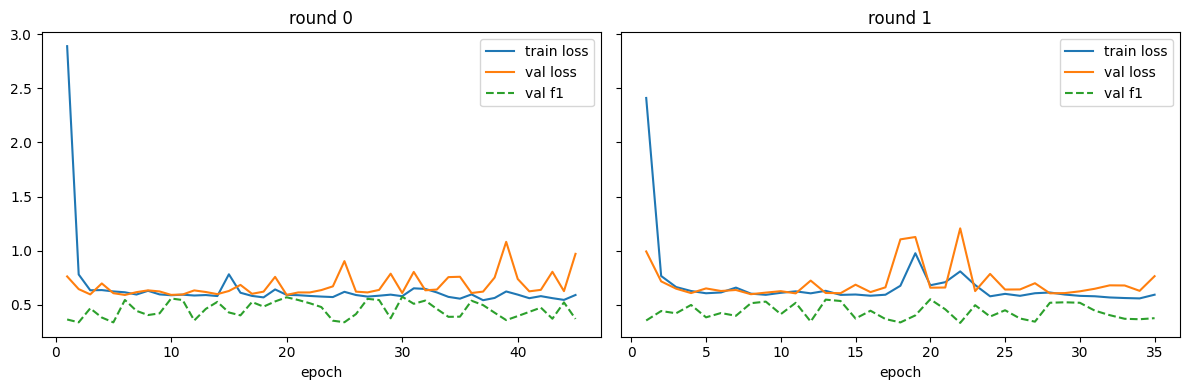

In [19]:
fig, axes = plt.subplots(1, len(histories), figsize=(6 * len(histories), 4), sharey=True)
if len(histories) == 1:
    axes = [axes]
for ax, hist, r in zip(axes, histories, range(len(histories))):
    df = pd.DataFrame(hist)
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    ax.plot(df["epoch"], df["val_f1"], label="val f1", linestyle="--")
    ax.set_title(f"round {r}")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()